⚖️ Credit Scoring Model (classification)

Credit Scoring Model Plan
Target: default_in_12_mo
Goal: Predict the probability of default (PD) for each SME over the next 12 months.
Type: Binary classification (0 = no default, 1 = default)

1. 🎯 Define Inputs & Prevent Leakage
❌ Features to Exclude (Check The code)
✅ Features to Include:
Everything else that describes the SME before a credit decision. These are the legitimate inputs.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import shap

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score, brier_score_loss, roc_curve, precision_recall_curve
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv(r"../Data/sme_synthetic_credit_data_FULL.csv")

In [5]:
# --- Define Columns ---
target = 'default_in_12_mo'
leakage_cols = [
    'default_in_12_mo', 'loss_given_default', 'credit_limit',
    'collateral_value', 'collateral_type', 'archetype', 'fraud_alert_flag', 'num_defaults_last_12mo'
]

# Drop leakage columns from feature list
features = [col for col in df.columns if col not in leakage_cols]

In [7]:
categorical_cols = df[features].select_dtypes(include='object').columns
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))

In [9]:
# Final features
X = df[features]
y = df[target]

# --- Train-Test Split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

In [13]:
xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42
)

calibrated_model = CalibratedClassifierCV(xgb_model, method='isotonic', cv=5)
calibrated_model.fit(X_train, y_train)

CalibratedClassifierCV(cv=5,
                       estimator=XGBClassifier(base_score=None, booster=None,
                                               callbacks=None,
                                               colsample_bylevel=None,
                                               colsample_bynode=None,
                                               colsample_bytree=0.8,
                                               device=None,
                                               early_stopping_rounds=None,
                                               enable_categorical=False,
                                               eval_metric='logloss',
                                               feature_types=None,
                                               feature_weights=None, gamma=None,
                                               grow_policy=None,
                                               importance_type=None,
                                               interaction_constraints=None,
                                               learning_rate=0.05, max_bin=None,
                                               max_cat_threshold=None,
                                               max_cat_to_onehot=None,
                                               max_delta_step=None, max_depth=5,
                                               max_leaves=None,
                                               min_child_weight=None,
                                               missing=nan,
                                               monotone_constraints=None,
                                               multi_strategy=None,
                                               n_estimators=500, n_jobs=None,
                                               num_parallel_tree=None, ...),
                       method='isotonic')

In [15]:
y_proba = calibrated_model.predict_proba(X_test)[:, 1]
y_pred = calibrated_model.predict(X_test)


In [17]:
auc = roc_auc_score(y_test, y_proba)
brier = brier_score_loss(y_test, y_proba)

print(f"AUC-ROC: {auc:.4f}")
print(f"Brier Score: {brier:.4f}")

AUC-ROC: 0.9756
Brier Score: 0.0413


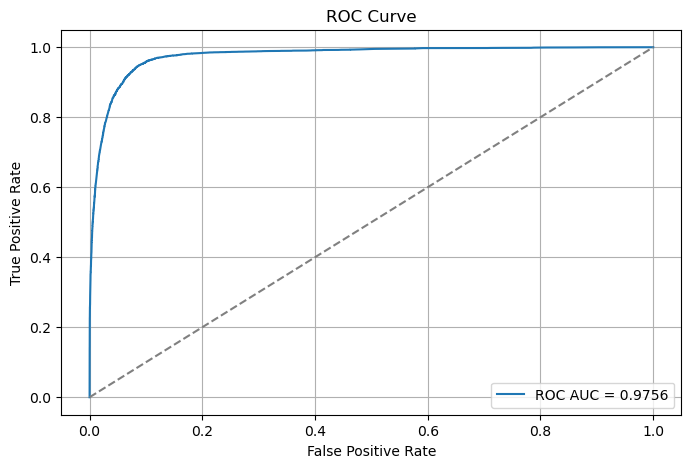

In [19]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, label=f"ROC AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

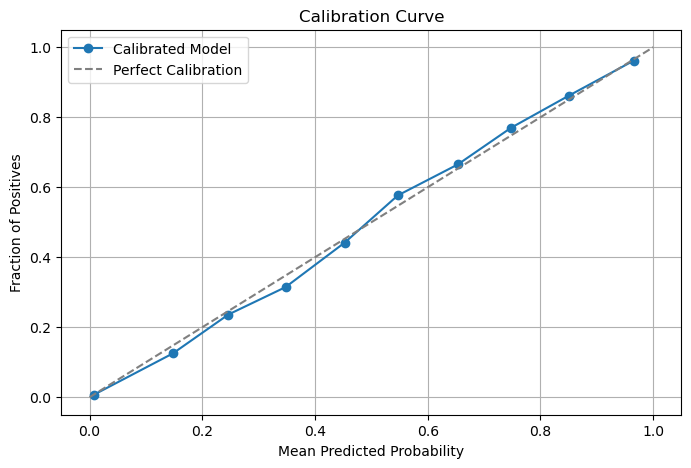

In [21]:
prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=10)
plt.figure(figsize=(8, 5))
plt.plot(prob_pred, prob_true, marker='o', label='Calibrated Model')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect Calibration')
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.title("Calibration Curve")
plt.legend()
plt.grid(True)
plt.show()

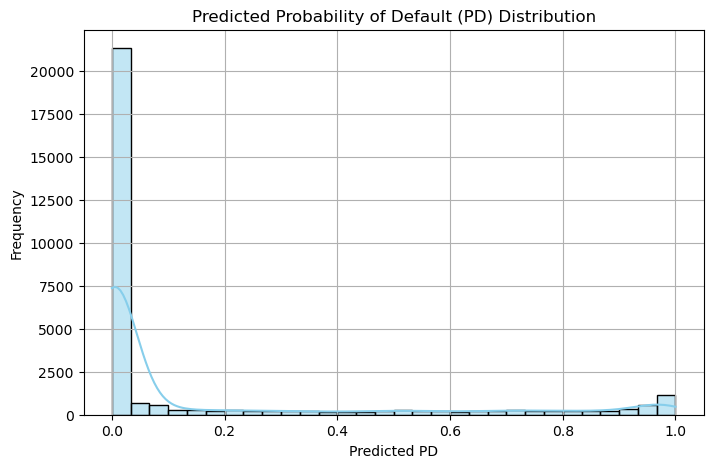

In [23]:
plt.figure(figsize=(8, 5))
sns.histplot(y_proba, bins=30, kde=True, color='skyblue')
plt.title("Predicted Probability of Default (PD) Distribution")
plt.xlabel("Predicted PD")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

100%|===================| 29953/30000 [05:44<00:00]        

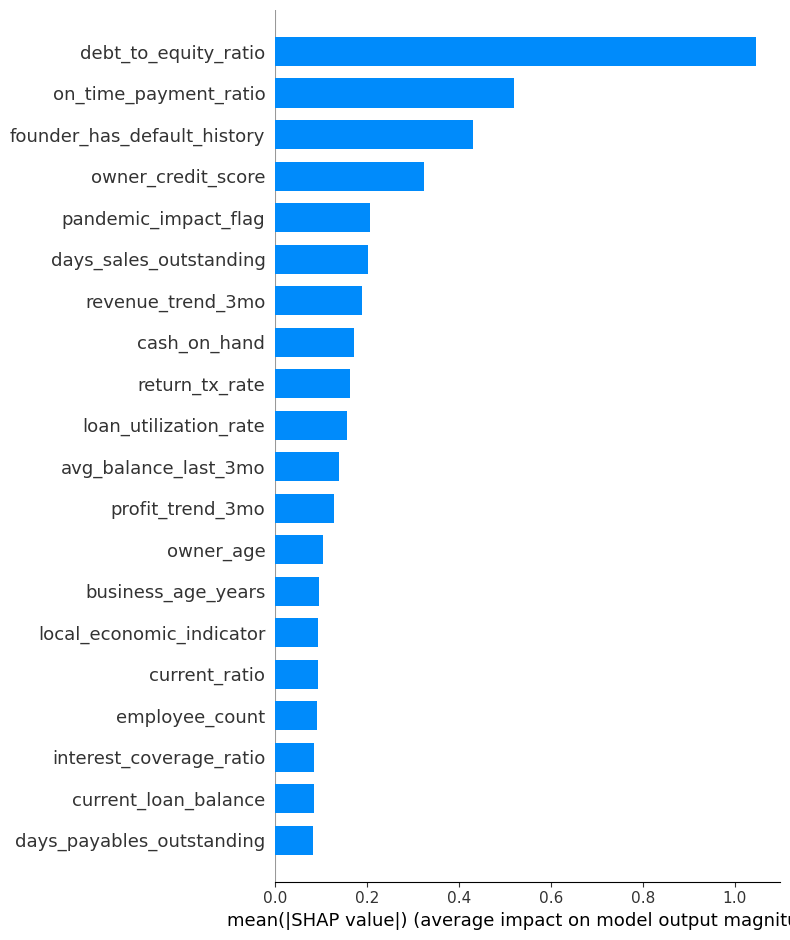

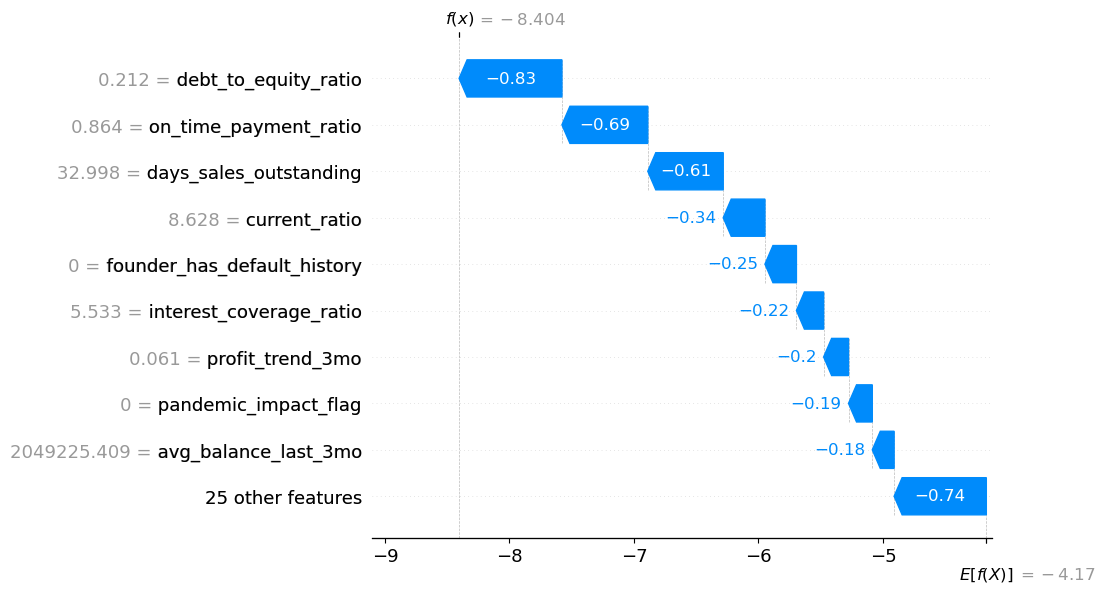

In [25]:
xgb_model.fit(X_train, y_train)  # Fit base model separately for SHAP

explainer = shap.Explainer(xgb_model, X_train)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test, plot_type="bar")
shap.plots.waterfall(shap_values[0])

In [27]:
import joblib

joblib.dump({
    "model": calibrated_model,
    "features": X_train.columns.tolist()
}, "pd_model_calibrated.pkl")

['pd_model_calibrated.pkl']